# NYC Yellow Taxi Data Visualization
Exploratory analysis of NYC Yellow Taxi trip records (2020–2025)

In [27]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('yellow_taxi_records')

## 1. Load & Aggregate Monthly Summary
We read each parquet file, compute monthly aggregates, and stitch them together.

In [28]:
records = []
for path in sorted(DATA_DIR.glob('*.parquet')):
    df = pd.read_parquet(path)
    # parse year/month from filename: yellow_taxi_YYYY_MM.parquet
    stem = path.stem  # e.g. yellow_taxi_2023_01
    parts = stem.split('_')
    year, month = int(parts[2]), int(parts[3])

    # basic cleaning: drop obviously bad rows
    df = df[
        (df['trip_distance'] > 0) &
        (df['fare_amount'] > 0) &
        (df['total_amount'] > 0) &
        (df['tpep_pickup_datetime'].dt.year == year)
    ].copy()

    df['trip_duration_min'] = (
        df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
    ).dt.total_seconds() / 60
    df = df[df['trip_duration_min'].between(1, 180)]

    records.append(dict(
        year=year, month=month,
        period=pd.Period(f'{year}-{month:02d}', 'M'),
        n_trips=len(df),
        avg_distance=df['trip_distance'].mean(),
        avg_fare=df['fare_amount'].mean(),
        avg_total=df['total_amount'].mean(),
        avg_tip=df['tip_amount'].mean(),
        avg_duration_min=df['trip_duration_min'].mean(),
        avg_passengers=df['passenger_count'].mean(),
        tip_rate=(df['tip_amount'] > 0).mean(),
        pct_airport=(
            df['RatecodeID'].isin([2, 3]).sum() / len(df)
            if 'RatecodeID' in df.columns else np.nan
        ),
    ))
    print(f'  {year}-{month:02d}: {len(df):,} trips')

monthly = pd.DataFrame(records).sort_values(['year', 'month']).reset_index(drop=True)
monthly['date'] = pd.to_datetime(monthly[['year', 'month']].assign(day=1))
print(f'\nTotal months loaded: {len(monthly)}')
monthly.head()

  2020-01: 6,279,175 trips
  2020-02: 6,184,883 trips
  2021-01: 1,329,406 trips
  2021-02: 1,330,978 trips
  2021-03: 1,874,383 trips
  2021-04: 2,113,761 trips
  2021-05: 2,445,883 trips
  2021-06: 2,769,621 trips
  2021-07: 2,752,896 trips
  2021-08: 2,719,545 trips
  2021-09: 2,877,403 trips
  2021-10: 3,388,332 trips
  2021-11: 3,404,069 trips
  2021-12: 3,143,711 trips
  2022-01: 2,409,257 trips
  2022-02: 2,917,306 trips
  2022-03: 3,548,957 trips
  2022-04: 3,520,321 trips
  2022-05: 3,502,080 trips
  2022-06: 3,462,211 trips
  2022-07: 3,091,005 trips
  2022-08: 3,066,081 trips
  2022-09: 3,096,902 trips
  2022-10: 3,569,917 trips
  2022-11: 3,151,954 trips
  2022-12: 3,295,806 trips
  2023-01: 2,986,777 trips
  2023-02: 2,839,106 trips
  2023-03: 3,314,336 trips
  2023-04: 3,207,206 trips
  2023-05: 3,423,850 trips
  2023-06: 3,218,455 trips
  2023-07: 2,817,095 trips
  2023-08: 2,726,970 trips
  2023-09: 2,710,327 trips
  2023-10: 3,353,711 trips
  2023-11: 3,190,121 trips
 

,year,month,period,n_trips,avg_distance,avg_fare,avg_total,avg_tip,avg_duration_min,avg_passengers,tip_rate,pct_airport,date
0,2020,1,2020-01,6279175,2.971821,12.546675,18.549492,2.184615,13.218415,1.518019,0.719120,0.025192,2020-01-01
1,2020,2,2020-02,6184883,2.898351,12.496459,18.514001,2.215890,13.578538,1.506674,0.732593,0.022914,2020-02-01
2,2021,1,2021-01,1329406,4.722531,12.021847,17.495465,1.948996,11.724020,1.415304,0.707903,0.010664,2021-01-01
3,2021,2,2021-02,1330978,4.253607,12.061672,17.599136,1.940125,12.587901,1.413402,0.695647,0.008008,2021-02-01
4,2021,3,2021-03,1874383,4.421835,12.106865,17.735728,1.973425,12.494357,1.404304,0.699522,0.009775,2021-03-01


## 2. Trip Volume Over Time

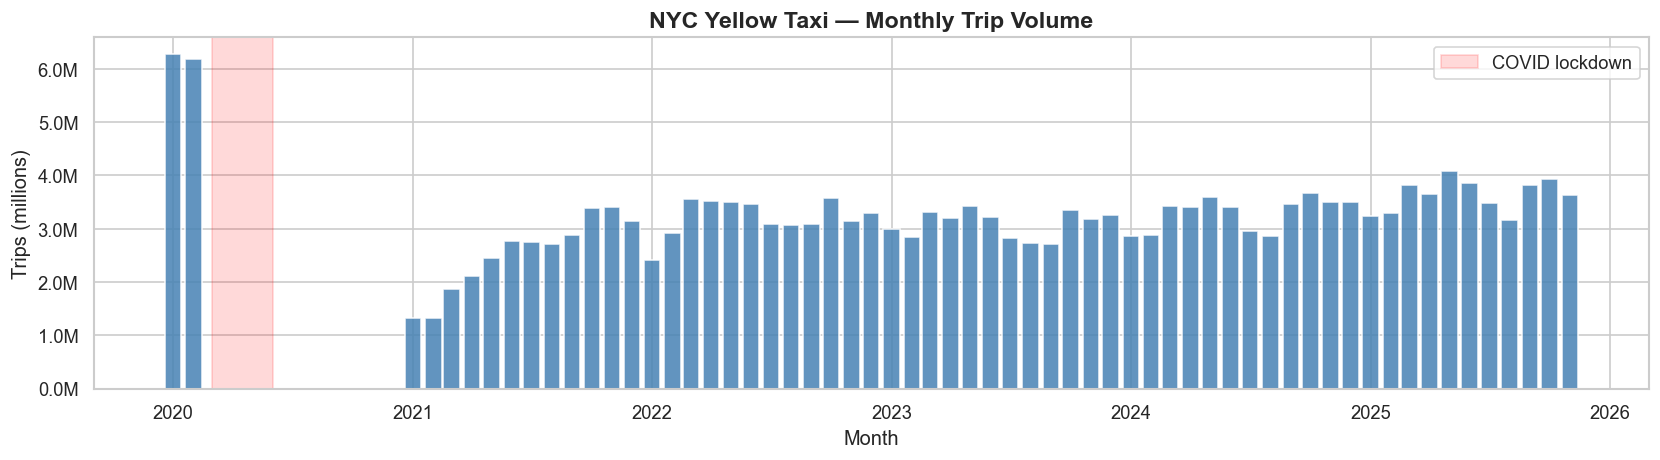

In [29]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(monthly['date'], monthly['n_trips'] / 1e6, width=25, color='steelblue', alpha=0.85)
ax.set_title('NYC Yellow Taxi — Monthly Trip Volume', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Trips (millions)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1fM'))
# annotate COVID dip
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-06-01'),
           alpha=0.15, color='red', label='COVID lockdown')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Fare & Tip Trends

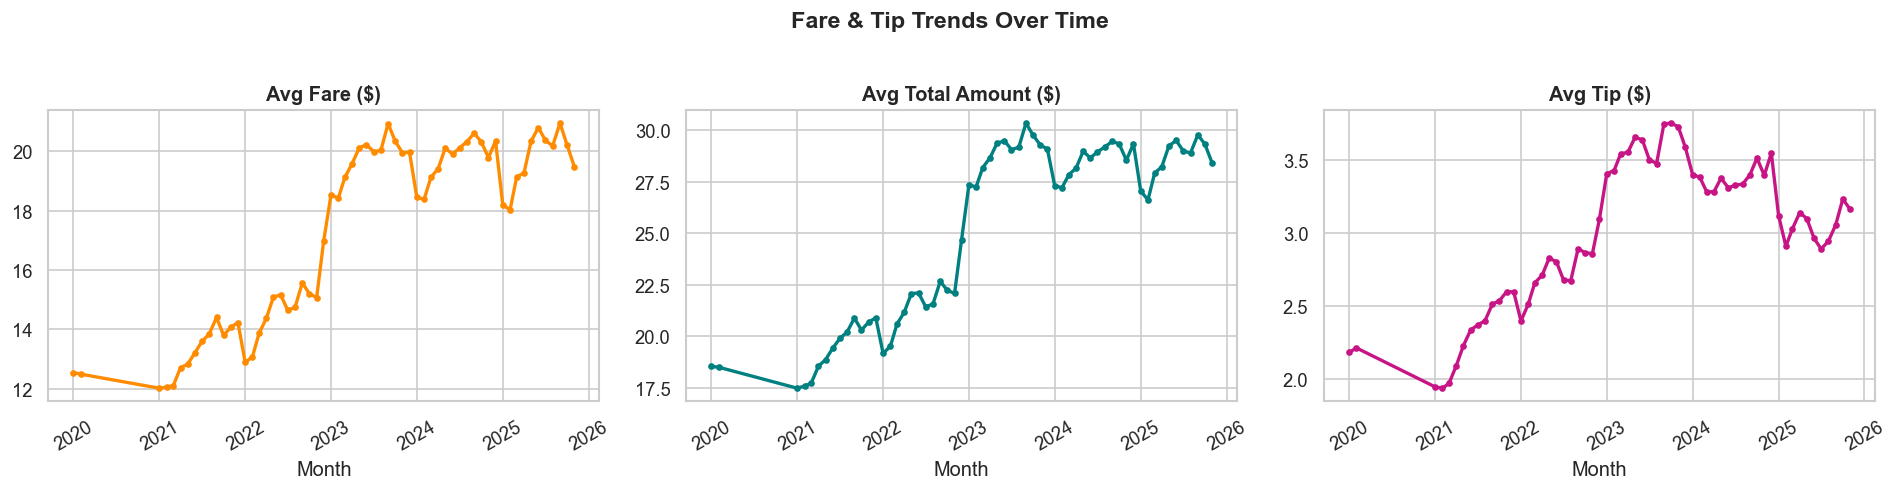

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

metrics = [
    ('avg_fare',  'Avg Fare ($)',       'darkorange'),
    ('avg_total', 'Avg Total Amount ($)', 'teal'),
    ('avg_tip',   'Avg Tip ($)',         'mediumvioletred'),
]

for ax, (col, label, color) in zip(axes, metrics):
    ax.plot(monthly['date'], monthly[col], color=color, linewidth=2, marker='o', markersize=3)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Month')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Fare & Tip Trends Over Time', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Average Trip Distance & Duration

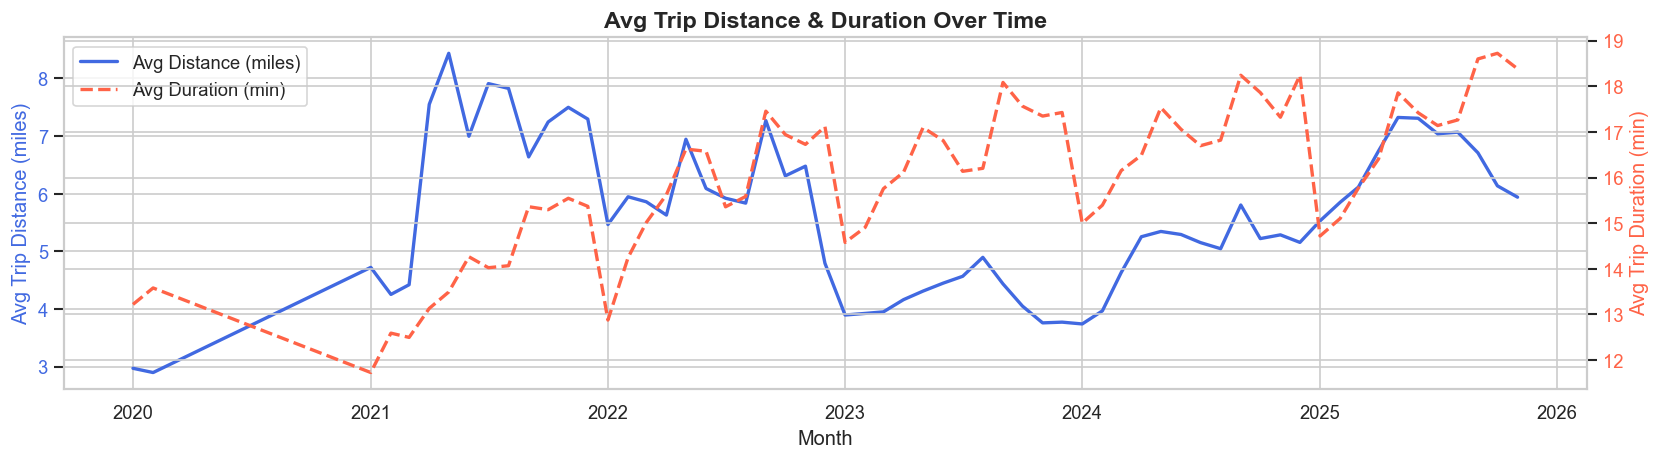

In [31]:
fig, ax1 = plt.subplots(figsize=(14, 4))
color1, color2 = 'royalblue', 'tomato'

ax1.plot(monthly['date'], monthly['avg_distance'], color=color1, linewidth=2, label='Avg Distance (miles)')
ax1.set_ylabel('Avg Trip Distance (miles)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(monthly['date'], monthly['avg_duration_min'], color=color2, linewidth=2, linestyle='--', label='Avg Duration (min)')
ax2.set_ylabel('Avg Trip Duration (min)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_title('Avg Trip Distance & Duration Over Time', fontsize=14, fontweight='bold')
ax1.set_xlabel('Month')
plt.tight_layout()
plt.show()

## 5. Tip Rate Over Time

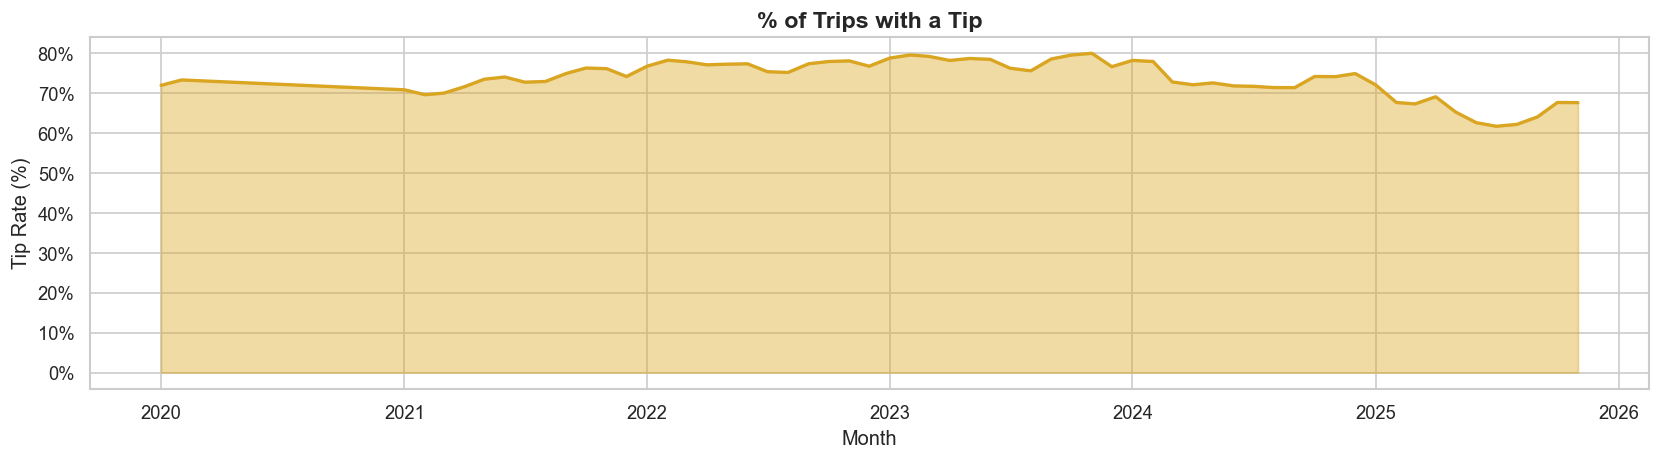

In [32]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(monthly['date'], monthly['tip_rate'] * 100, alpha=0.4, color='goldenrod')
ax.plot(monthly['date'], monthly['tip_rate'] * 100, color='goldenrod', linewidth=2)
ax.set_title('% of Trips with a Tip', fontsize=14, fontweight='bold')
ax.set_ylabel('Tip Rate (%)')
ax.set_xlabel('Month')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

## 6. Year-over-Year Seasonality (Trip Volume)

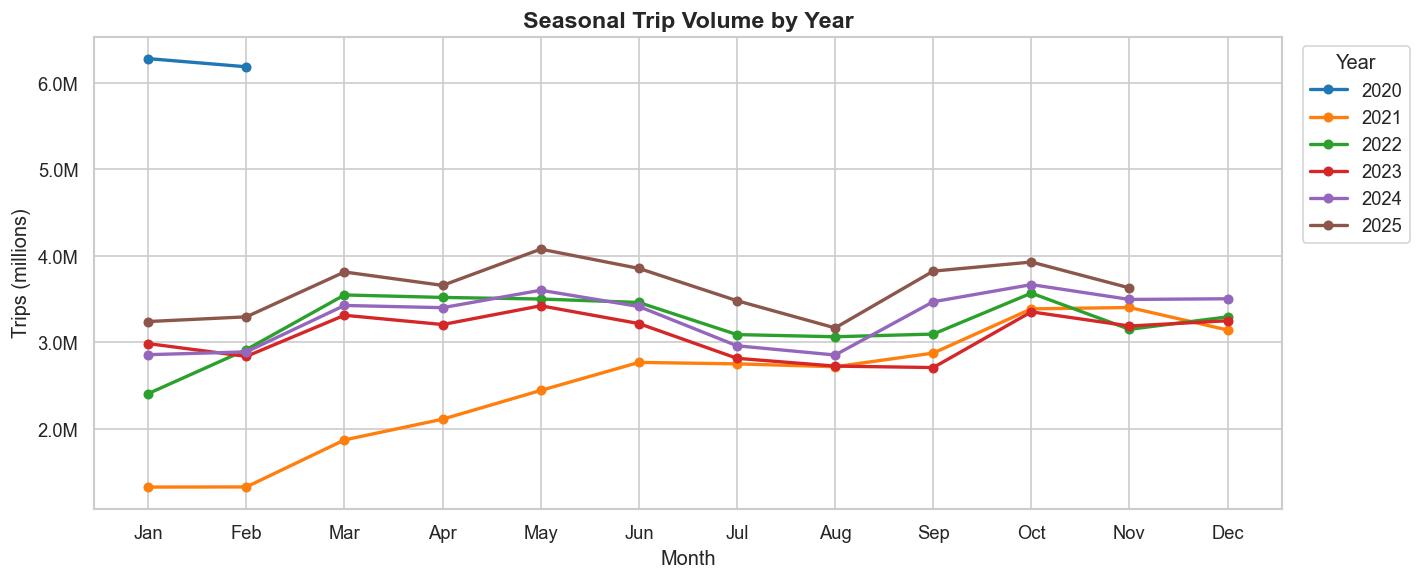

In [33]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot = monthly.pivot_table(index='month', columns='year', values='n_trips')

fig, ax = plt.subplots(figsize=(12, 5))
for year in pivot.columns:
    ax.plot(pivot.index, pivot[year] / 1e6, marker='o', label=str(year), linewidth=2, markersize=5)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title('Seasonal Trip Volume by Year', fontsize=14, fontweight='bold')
ax.set_ylabel('Trips (millions)')
ax.set_xlabel('Month')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1fM'))
ax.legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 7. Deep-Dive: Single Month Sample Analysis
Load one month fully to look at distributions.

In [34]:
SAMPLE_FILE = DATA_DIR / 'yellow_taxi_2023_06.parquet'

df = pd.read_parquet(SAMPLE_FILE)
df = df[
    (df['trip_distance'].between(0.1, 50)) &
    (df['fare_amount'].between(1, 200)) &
    (df['total_amount'].between(1, 300)) &
    (df['tpep_pickup_datetime'].dt.year == 2023)
].copy()
df['trip_duration_min'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60
df = df[df['trip_duration_min'].between(1, 120)]
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_dow']  = df['tpep_pickup_datetime'].dt.day_name()
print(f'Sample rows: {len(df):,}')
df[['trip_distance','fare_amount','total_amount','tip_amount','trip_duration_min']].describe().round(2)

Sample rows: 3,214,025


,trip_distance,fare_amount,total_amount,tip_amount,trip_duration_min
count,3214025.00,3214025.00,3214025.00,3214025.00,3214025.00
mean,3.62,20.00,29.25,3.63,16.77
std,4.58,17.56,22.33,4.01,13.33
min,0.10,1.00,2.00,0.00,1.00
25%,1.10,9.30,16.13,1.00,7.90
50%,1.86,13.50,21.36,2.90,12.93
75%,3.60,22.60,31.35,4.54,21.02
max,49.86,200.00,294.81,222.00,120.00


### 7a. Fare & Distance Distributions

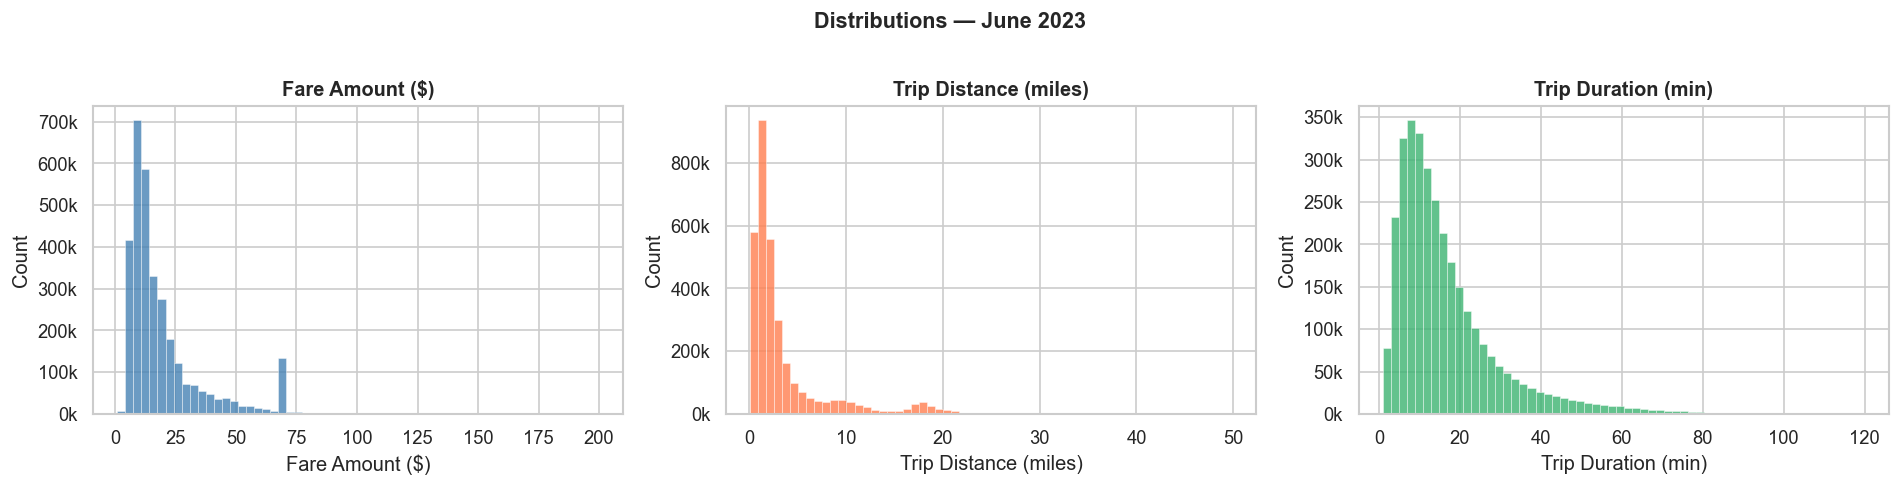

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, color, title in zip(
    axes,
    ['fare_amount', 'trip_distance', 'trip_duration_min'],
    ['steelblue', 'coral', 'mediumseagreen'],
    ['Fare Amount ($)', 'Trip Distance (miles)', 'Trip Duration (min)'],
):
    ax.hist(df[col], bins=60, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

fig.suptitle('Distributions — June 2023', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 7b. Pickup Volume by Hour and Day of Week

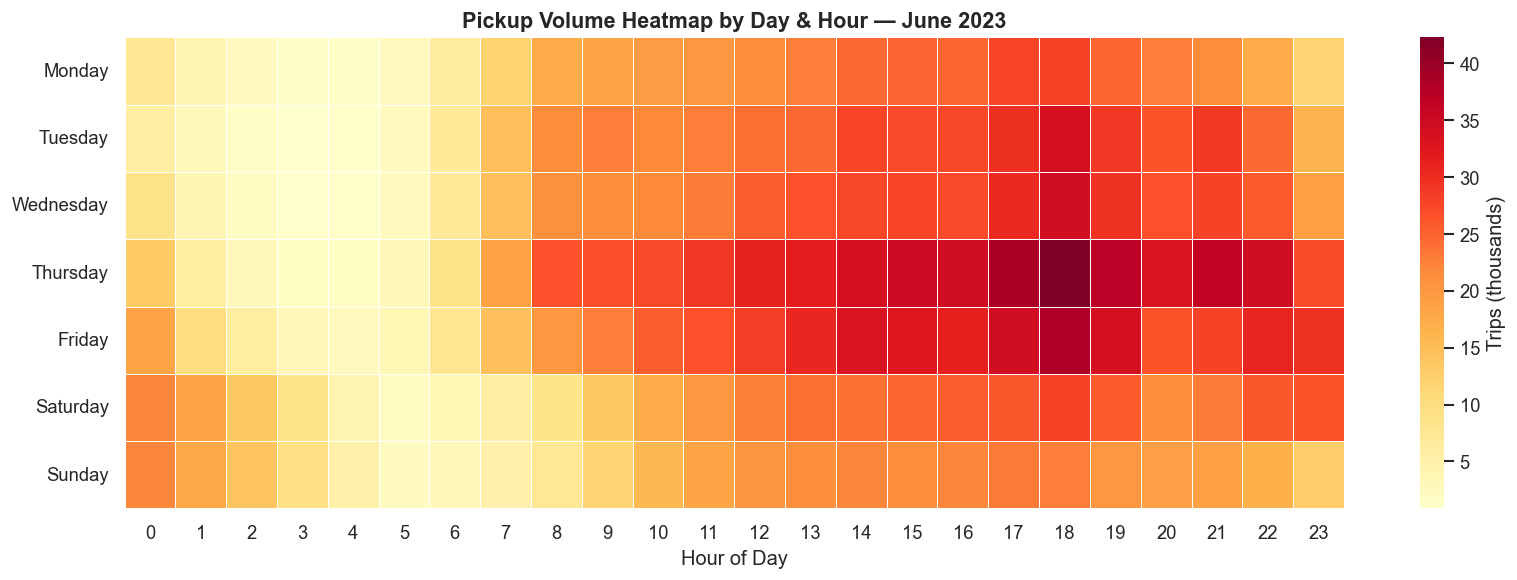

In [36]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heatmap_data = (
    df.groupby(['pickup_dow', 'pickup_hour'])
      .size()
      .unstack(fill_value=0)
      .reindex(day_order)
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    heatmap_data / 1e3, ax=ax,
    cmap='YlOrRd', linewidths=0.3,
    cbar_kws={'label': 'Trips (thousands)'},
    fmt='.0f', annot=False
)
ax.set_title('Pickup Volume Heatmap by Day & Hour — June 2023', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 7c. Fare vs Distance Scatter (sampled)

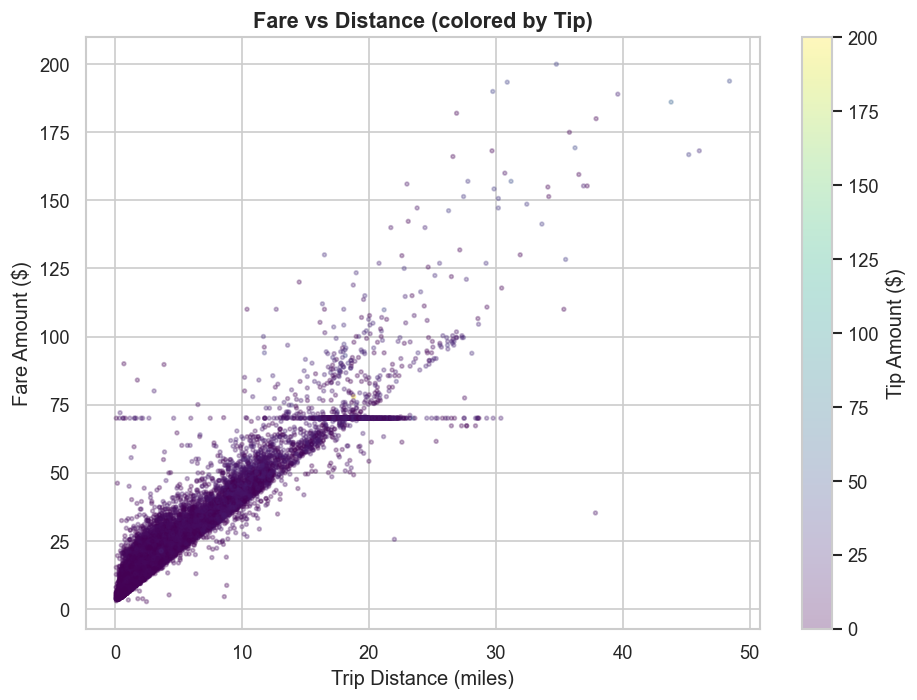

In [37]:
sample = df.sample(n=min(30_000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    sample['trip_distance'], sample['fare_amount'],
    c=sample['tip_amount'], cmap='viridis',
    alpha=0.3, s=5, rasterized=True
)
plt.colorbar(sc, ax=ax, label='Tip Amount ($)')
ax.set_xlabel('Trip Distance (miles)')
ax.set_ylabel('Fare Amount ($)')
ax.set_title('Fare vs Distance (colored by Tip)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7d. Top 20 Pickup Locations

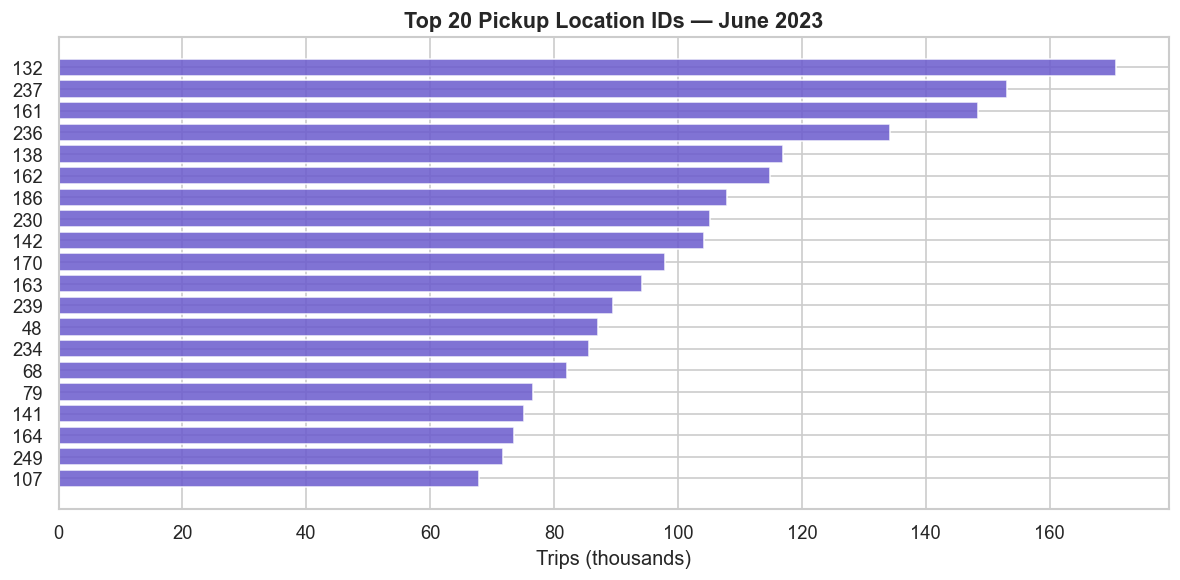

In [38]:
top_pu = df['PULocationID'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_pu.index.astype(str), top_pu.values / 1e3, color='slateblue', alpha=0.85)
ax.invert_yaxis()
ax.set_xlabel('Trips (thousands)')
ax.set_title('Top 20 Pickup Location IDs — June 2023', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7e. Payment Type Breakdown

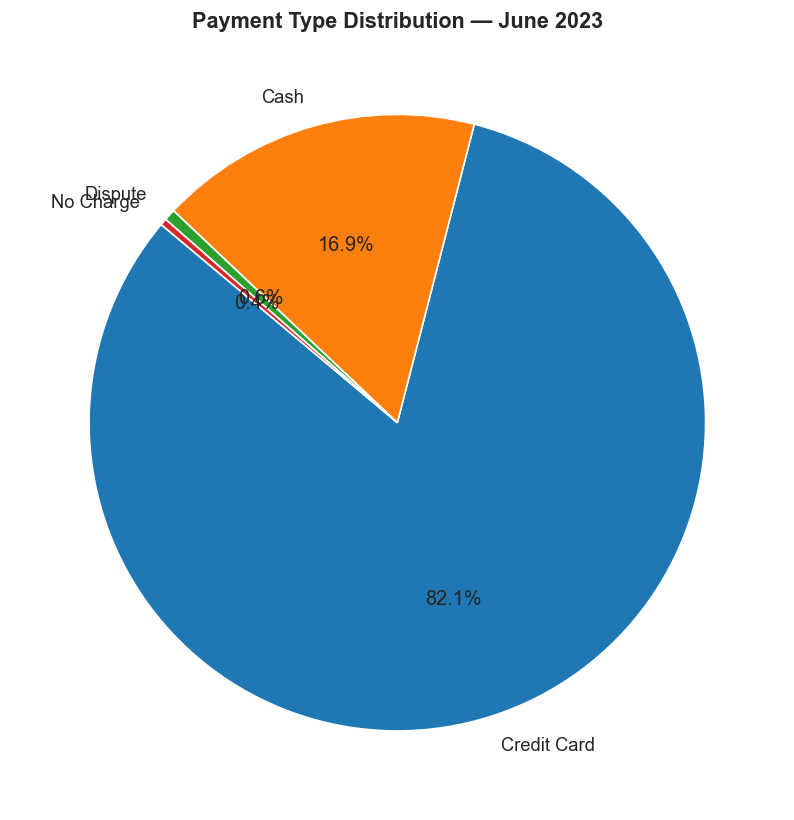

In [39]:
# 1=Credit card, 2=Cash, 3=No charge, 4=Dispute, 5=Unknown, 6=Voided trip
payment_labels = {1: 'Credit Card', 2: 'Cash', 3: 'No Charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided'}
pay_counts = df['payment_type'].map(payment_labels).value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    pay_counts,
    labels=pay_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('tab10', len(pay_counts))
)
ax.set_title('Payment Type Distribution — June 2023', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Choropleth Map: Avg Fare & Tip by Pickup Zone
Interactive maps showing which NYC taxi zones generate the highest average fares and tips.

In [ ]:
import folium
import requests

# Avg fare/tip grouped by pickup location
zone_stats_pickup = (
    df.groupby('PULocationID')
      .agg(avg_fare=('fare_amount', 'mean'),
           avg_tip=('tip_amount',  'mean'),
           n_trips=('fare_amount', 'count'))
      .reset_index()
      .rename(columns={'PULocationID': 'LocationID'})
)

# Avg fare/tip grouped by dropoff location
zone_stats_dropoff = (
    df.groupby('DOLocationID')
      .agg(avg_fare=('fare_amount', 'mean'),
           avg_tip=('tip_amount',  'mean'),
           n_trips=('fare_amount', 'count'))
      .reset_index()
      .rename(columns={'DOLocationID': 'LocationID'})
)

# Merge zone names onto both
lookup = pd.read_csv('taxi_zone_lookup (1).csv')
lookup.columns = ['LocationID', 'Borough', 'Zone', 'service_zone']

for stats in [zone_stats_pickup, zone_stats_dropoff]:
    merged = stats.merge(lookup, on='LocationID', how='left')
    stats['label'] = merged['Zone'] + ' (' + merged['Borough'] + ')'

print(f"Pickup zones:  {len(zone_stats_pickup)}")
print(f"Dropoff zones: {len(zone_stats_dropoff)}")
zone_stats_pickup.sort_values('avg_fare', ascending=False).head(5)

Pickup zones:  254
Dropoff zones: 260


96      99
5        6
147    156
0        1
194    206
Name: LocationID, dtype: int32

In [56]:
# ── 3. Load NYC Taxi Zone boundaries from TLC shapefile ──────────────────────
# The TLC publishes zone boundaries as a zipped shapefile (.shp = polygon geometry,
# .dbf = attributes, .prj = coordinate system).  geopandas reads all three together.

import io, zipfile, urllib.request
import geopandas as gpd
import altair as alt

TLC_ZIP = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"
print("Downloading taxi zone shapefile from TLC...")

# Fetch zip into memory (io.BytesIO lets zipfile treat raw bytes as a file)
with urllib.request.urlopen(TLC_ZIP) as resp:
    zip_bytes = resp.read()

zf = zipfile.ZipFile(io.BytesIO(zip_bytes))
shp_name = next(n for n in zf.namelist() if n.endswith('.shp'))  # find .shp dynamically
extract_dir = '/tmp/taxi_zones2/'
zf.extractall(extract_dir)

# to_crs('EPSG:4326') converts from NY local feet → WGS 84 lat/lon that Altair expects
gdf = gpd.read_file(extract_dir + shp_name).to_crs('EPSG:4326')
gdf['LocationID'] = gdf['LocationID'].astype(int)
print(f"Shapefile loaded: {len(gdf)} zones")

def merge_and_clean(gdf, stats):
    """Merge zone stats into the GeoDataFrame and clean up columns."""
    m = gdf.merge(stats, on='LocationID', how='left')
    m['avg_fare']   = m['avg_fare'].round(2)
    m['avg_tip']    = m['avg_tip'].round(2)
    m['n_trips']    = m['n_trips'].fillna(0).astype(int)
    m['zone_label'] = m['label'].fillna(m['zone'])  # fallback to shapefile name
    return m

gdf_pickup  = merge_and_clean(gdf, zone_stats_pickup)
gdf_dropoff = merge_and_clean(gdf, zone_stats_dropoff)
print("Pickup GDF:", len(gdf_pickup), "| Dropoff GDF:", len(gdf_dropoff))

Shapefile loaded: 263 zones
Pickup GDF: 263 | Dropoff GDF: 263


In [74]:
import folium, html as html_lib

def build_map_html(gdf, metric, scheme, legend_title):
    """Build a folium choropleth and return its full HTML as a string."""
    m = folium.Map(location=[40.72, -73.95], zoom_start=11, tiles='CartoDB positron')

    choropleth = folium.Choropleth(
        geo_data=gdf.__geo_interface__,
        data=gdf[['LocationID', metric]].dropna(),
        columns=['LocationID', metric],
        key_on='feature.properties.LocationID',
        fill_color=scheme,
        fill_opacity=0.75,
        line_opacity=0.3,
        nan_fill_color='#d3d3d3',
        legend_name=legend_title,
        highlight=True,
    ).add_to(m)

    # Inject per-zone stats into feature properties for the tooltip
    for feat in choropleth.geojson.data['features']:
        loc_id = feat['properties'].get('LocationID')
        row = gdf[gdf['LocationID'] == loc_id]
        if not row.empty:
            r = row.iloc[0]
            feat['properties']['avg_fare']   = round(float(r['avg_fare']), 2) if pd.notna(r['avg_fare']) else 'N/A'
            feat['properties']['avg_tip']    = round(float(r['avg_tip']),  2) if pd.notna(r['avg_tip'])  else 'N/A'
            feat['properties']['n_trips']    = int(r['n_trips'])
            feat['properties']['zone_label'] = r['zone_label'] if pd.notna(r['zone_label']) else 'Unknown'

    choropleth.geojson.add_child(
        folium.features.GeoJsonTooltip(
            fields=['zone_label', 'avg_fare', 'avg_tip', 'n_trips'],
            aliases=['Zone:', 'Avg Fare ($):', 'Avg Tip ($):', 'Trips:'],
            sticky=False, style='font-size:12px;'
        )
    )

    return m.get_root().render()  # return full HTML string instead of saving to file

In [ ]:
# Build all 4 maps and combine into one HTML with a dropdown selector.
# Each map is embedded in an <iframe srcdoc="..."> so their Leaflet instances
# are fully isolated and don't conflict with each other.

MAPS = [
    ('Avg Fare — Pickup',  gdf_pickup,  'avg_fare', 'YlOrRd', 'Average Fare ($) by Pickup Zone'),
    ('Avg Fare — Dropoff', gdf_dropoff, 'avg_fare', 'YlOrRd', 'Average Fare ($) by Dropoff Zone'),
    ('Avg Tip — Pickup',   gdf_pickup,  'avg_tip',  'YlGn',   'Average Tip ($) by Pickup Zone'),
    ('Avg Tip — Dropoff',  gdf_dropoff, 'avg_tip',  'YlGn',   'Average Tip ($) by Dropoff Zone'),
]

# ── Derive time range label from the sample file name ────────────────────────
# SAMPLE_FILE is defined in section 7 as e.g. yellow_taxi_2023_06.parquet
parts = SAMPLE_FILE.stem.split('_')   # ['yellow', 'taxi', '2023', '06']
import calendar
year, month = int(parts[2]), int(parts[3])
TIME_RANGE = f"{calendar.month_name[month]} {year}"   # e.g. "June 2023"

print(f"Building maps for {TIME_RANGE} (this may take a moment)...")
map_htmls = [(label, build_map_html(gdf, metric, scheme, legend))
             for label, gdf, metric, scheme, legend in MAPS]
print("Done.")

# ── Assemble combined HTML ────────────────────────────────────────────────────
options_html = '\n'.join(
    f'<option value="{i}">{label}</option>'
    for i, (label, _) in enumerate(map_htmls)
)

frames_html = '\n'.join(
    f'''<div id="frame-{i}" class="map-frame" style="display:{'block' if i == 0 else 'none'}">
  <iframe srcdoc="{html_lib.escape(html_str)}" style="width:100%;height:calc(100vh - 60px);border:none;"></iframe>
</div>'''
    for i, (_, html_str) in enumerate(map_htmls)
)

combined = f"""<!DOCTYPE html>
<html>
<head>
  <meta charset="utf-8">
  <title>NYC Taxi Zone Maps</title>
  <style>
    * {{ box-sizing: border-box; margin: 0; padding: 0; }}
    body {{ font-family: sans-serif; }}
    #toolbar {{
      display: flex;
      align-items: center;
      gap: 16px;
      padding: 0 16px;
      height: 60px;
      background: #2c2c2c;
      color: #fff;
    }}
    #toolbar h1 {{ font-size: 16px; font-weight: 600; white-space: nowrap; }}
    #time-badge {{
      font-size: 12px;
      background: #555;
      padding: 3px 8px;
      border-radius: 12px;
      white-space: nowrap;
    }}
    /* push the dropdown to the right */
    #toolbar .spacer {{ flex: 1; }}
    #toolbar label {{ font-size: 13px; color: #ccc; }}
    #viz-select {{
      font-size: 13px;
      padding: 6px 10px;
      border-radius: 4px;
      border: none;
      cursor: pointer;
    }}
  </style>
</head>
<body>
  <div id="toolbar">
    <h1>NYC Yellow Taxi — Zone Analysis</h1>
    <span id="time-badge">&#128197; {TIME_RANGE}</span>
    <div class="spacer"></div>
    <label for="viz-select">View:</label>
    <select id="viz-select" onchange="showMap(this.value)">
{options_html}
    </select>
  </div>

{frames_html}

  <script>
    function showMap(idx) {{
      document.querySelectorAll('.map-frame').forEach(function(d) {{
        d.style.display = 'none';
      }});
      document.getElementById('frame-' + idx).style.display = 'block';
    }}
  </script>
</body>
</html>"""

OUTPUT = 'taxi_zone_maps.html'
with open(OUTPUT, 'w', encoding='utf-8') as f:
    f.write(combined)
print(f"Saved: {OUTPUT}")